In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# parent directory to path for imports
sys.path.append(str(Path.cwd().parent))

#  import utility functions from existing modules
from train_cvae import load_data, CVAE, one_hot
from ae_utils import _constuct_latent_vectors_list, _reconstuct_from_latent_vectors_list
from ae_utils import _plot_latent_space, _save_vectors_to_csv


In [2]:
# config
root = Path.cwd().parent
dataset_type = 'adima'  # Choose: 'mnist' or 'adima'

# model config
if dataset_type == 'mnist':
    checkpoint_path = './runs/mnist1602_l3_1/vae_1.pth'
    input_dim = 784  # 28x28
    latent_dim = 3
    data_csv = None  # MNIST is from torchvision
else:  # adima
    checkpoint_path = './runs/cvae_adima_l2_2/vae_1.pth'
    #checkpoint_path = './runs/1502/vae_1.pth'
    input_dim = 19
    latent_dim = 2
    data_csv = root / 'data/adima/training/fixed_current_training_data.csv'

print(f"dataset: {dataset_type}")
print(f"checkpoint: {checkpoint_path}")
print(f"input dim: {input_dim}, latent dim: {latent_dim}")

dataset: adima
checkpoint: ./runs/cvae_adima_l2_2/vae_1.pth
input dim: 19, latent dim: 2


In [3]:
# load data
X_train_tensor, X_valid_tensor, X, _, y_train = load_data(
    data_csv=data_csv, 
    dataset=dataset_type, 
    single_class=None
)

print(f"training shape: {X_train_tensor.shape}")
print(f"valid shape: {X_valid_tensor.shape}")
print(f"labels shape: {y_train.shape}")

####################################################################
# for the vcae
label_digits = {"blue": 0, "green": 1, "red": 2, "yellow": 3}
y_train_mapped = y_train.map(label_digits).astype(int)
labels_tensor = torch.tensor(y_train_mapped.values, dtype=torch.long)
one_hot_labels = F.one_hot(labels_tensor, num_classes=4).float()
y_train_one_hot = one_hot_labels

# grab the 10 samples
sample_indices = np.random.choice(len(X_train_tensor), 10, replace=False)
X_samples = X_train_tensor[sample_indices]
y_samples = y_train.iloc[sample_indices] if hasattr(y_train, 'iloc') else y_train[sample_indices]



labels head(): 0    blue
1    blue
2    blue
3    blue
4    blue
Name: Spannung, dtype: object
training shape: torch.Size([1440, 19])
valid shape: torch.Size([160, 19])
labels shape: (1440,)


In [4]:
# encode the training dataset
ae_type = 2  # 1 for VAE, 0 for AE, 3 for cvae
print("type(y_train):", type(y_train))
print("y_train.shape:", y_train.shape)
print("first y_train element:", y_train[0])

latent_vectors_all = _constuct_latent_vectors_list(
    checkpoint_path=checkpoint_path,
    X_training_tensor=X_train_tensor,
    input_dim=input_dim,
    latent_dim=latent_dim,
    ae_type=ae_type,
    c=y_train_one_hot
)

print(f"latent vectors shape: {latent_vectors_all.shape}")

# Encode the selected samples
latent_samples = _constuct_latent_vectors_list(
    checkpoint_path=checkpoint_path,
    X_training_tensor=X_samples,
    input_dim=input_dim,
    latent_dim=latent_dim,
    ae_type=ae_type,
    c=y_train_one_hot
)

type(y_train): <class 'pandas.core.series.Series'>
y_train.shape: (1440,)
first y_train element: blue
Sequential(
  (0): Linear(in_features=23, out_features=64, bias=True)
  (1): ReLU()
)
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch.Size([1, 19]) c_i torch.Size([1, 4])
sample torch

In [5]:
# reconstruct
reconstructed_samples = _reconstuct_from_latent_vectors_list(
    checkpoint_path=checkpoint_path,
    latent_vectors=latent_samples,
    input_dim=input_dim,
    latent_dim=latent_dim,
    ae_type=ae_type,
    c=y_train_one_hot
)

sample:  tensor([[ 0.0157, -0.0230]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 0., 0., 1.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0036, -0.0078]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 0., 1., 0.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0038, -0.0086]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 0., 1., 0.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0190, -0.0274]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 1., 0., 0.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0038, -0.0086]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 0., 1., 0.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0076, -0.0161]]) <class 'torch.Tensor'> torch.Size([1, 2])
c_:  tensor([[0., 0., 0., 1.]]) <class 'torch.Tensor'> torch.Size([1, 4])
sample:  tensor([[ 0.0038, -0.0086]]) <class 'torch.Tensor'> torch.Size([1, 

2D latent space


/home/elsheikh/repos/agile-ima-python/autoencoders/ae_utils.py:76: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=y_train, cmap='viridis', s=5)


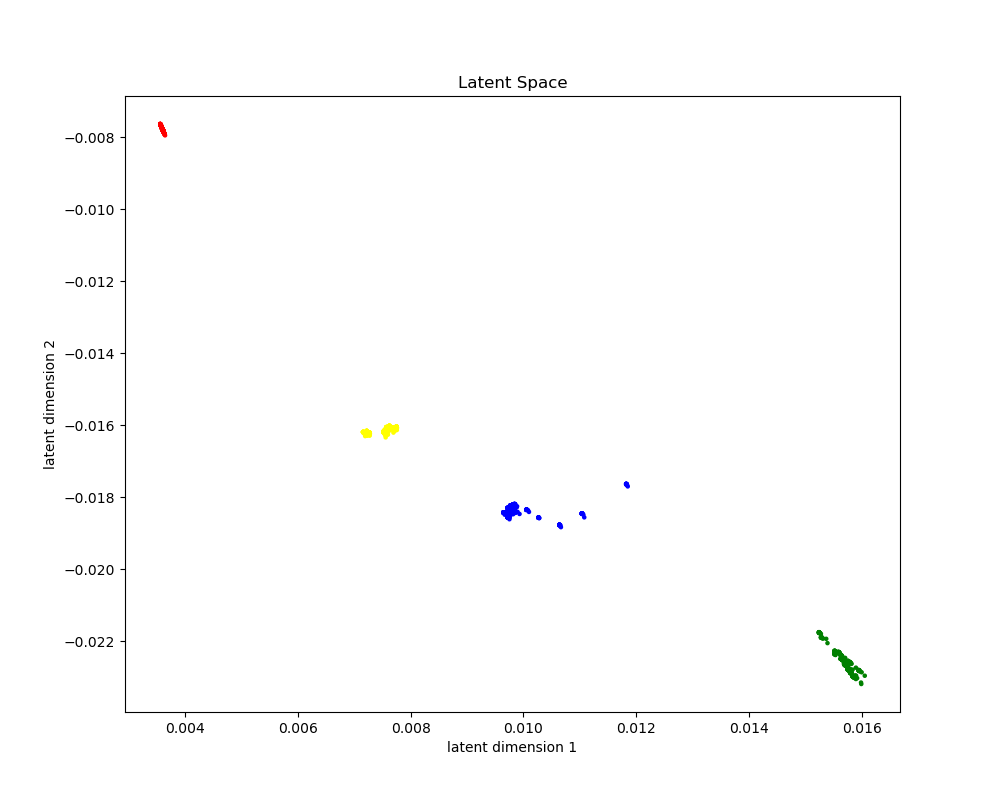

In [6]:
#%matplotlib inline
%matplotlib widget
# plot the full latent space
plt.figure(figsize=(10, 8))
_plot_latent_space(latent_vectors_all, y_train, show=True)

In [7]:
if dataset_type == 'mnist':
    # show mnist 
    n_cols = 3
    n_rows = (num_samples_to_show + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(14, 3*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, sample_id in enumerate(sample_indices):
        row = idx // n_cols
        col_input = (idx % n_cols) * 2
        col_recon = col_input + 1
        
        # original input
        img_input = X_samples[idx].numpy().reshape(28, 28)
        axes[row, col_input].imshow(img_input, cmap='gray')
        axes[row, col_input].set_title(f'Input #{idx+1}')
        axes[row, col_input].axis('off')
        
        # reconstructed
        img_recon = reconstructed_samples[idx].reshape(28, 28)
        axes[row, col_recon].imshow(img_recon, cmap='gray')
        axes[row, col_recon].set_title(f'Reconstructed\nMSE: {reconstruction_error[idx]:.4f}')
        axes[row, col_recon].axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    # for ADIMA data, create a line plot comparison
    fig, axes = plt.subplots(min(5, num_samples_to_show), 1, figsize=(12, 3*min(5, num_samples_to_show)))
    if num_samples_to_show == 1:
        axes = [axes]
    
    for idx in range(min(5, num_samples_to_show)):
        ax = axes[idx]
        original = X_samples[idx].numpy()
        recon = reconstructed_samples[idx]
        
        ax.plot(original, 'b-o', label='Original', alpha=0.7)
        ax.plot(recon, 'r--s', label='Reconstructed', alpha=0.7)
        ax.set_title(f'Sample {idx+1} (MSE: {reconstruction_error[idx]:.6f})')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.xlabel('Feature Index')
    plt.tight_layout()
    plt.show()

print("✓ Input vs. Reconstruction visualization complete")

NameError: name 'num_samples_to_show' is not defined